In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv("Mall_Customers.csv")
print("\nFirst 5 Rows")
print(df.head())


First 5 Rows
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [19]:
# ============================================================
# STEP 3: BASIC DATA EXPLORATION
# ============================================================

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())





Dataset Shape
(200, 6)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
 5   Cluster                 200 non-null    int32 
dtypes: int32(1), int64(4), object(1)
memory usage: 8.7+ KB
None

Missing Values
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Cluster                   0
dtype: int64

Statistical Summary
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)  \
count  200.000000  200.000000          200.000000              200.000000  

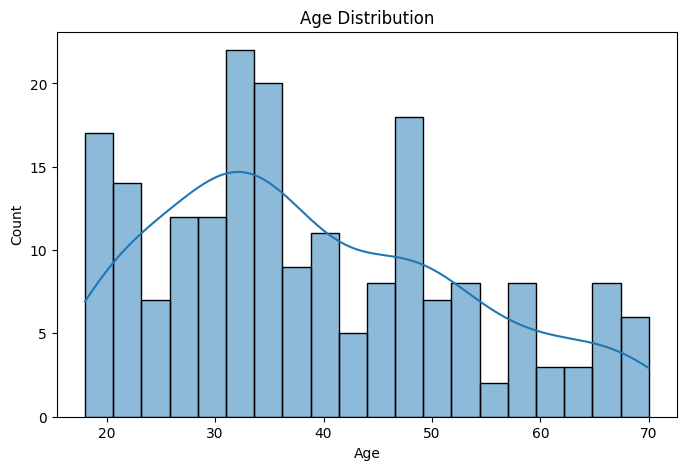

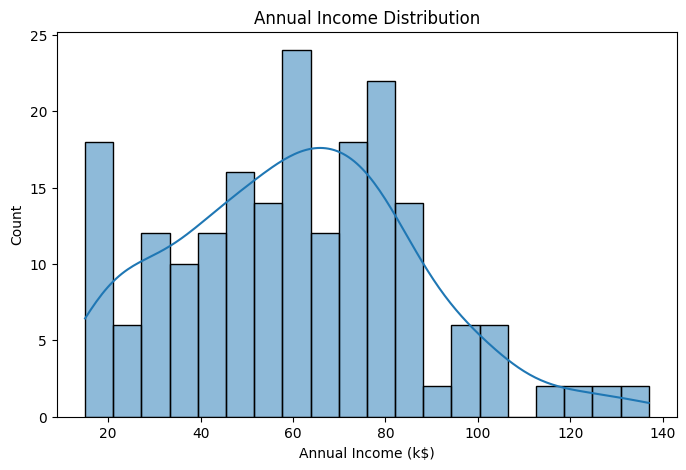

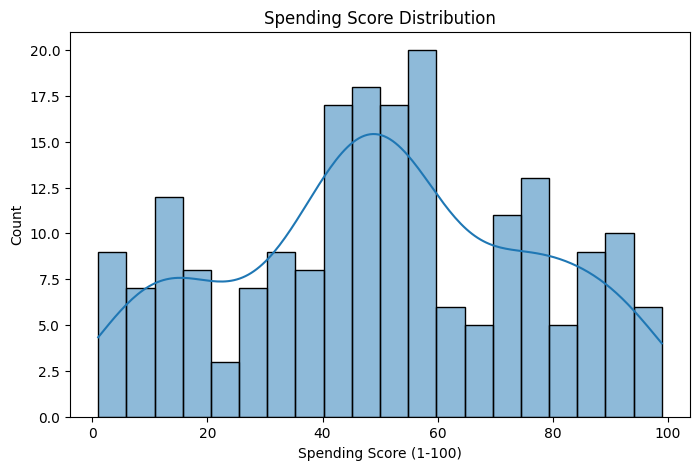

In [21]:
# ============================================================
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()


In [ ]:


# ============================================================
# STEP 5: FEATURE SELECTION
# ============================================================
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
print("\nSelected Features")
print(X.head())


Selected Features
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [ ]:

# ============================================================
# STEP 6: FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
print("\nScaled Data Shape")
print(X_scaled.shape)


Scaled Data Shape
(200, 2)


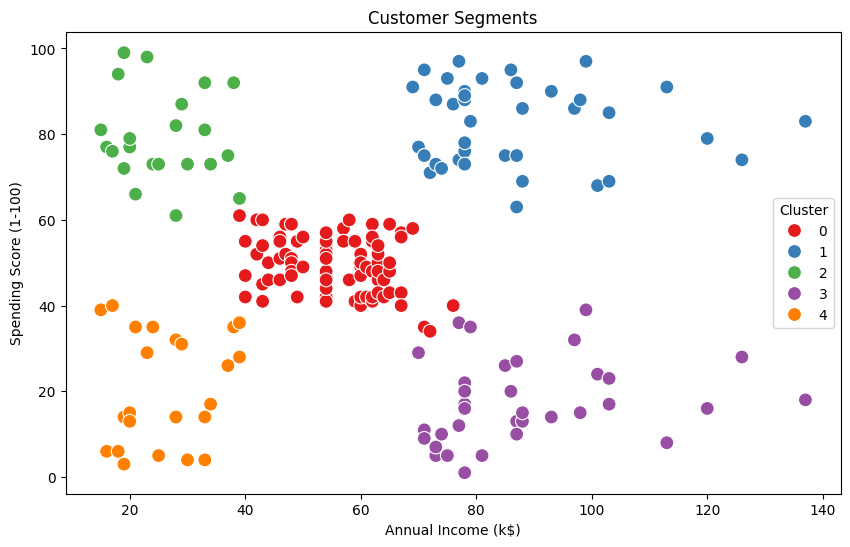

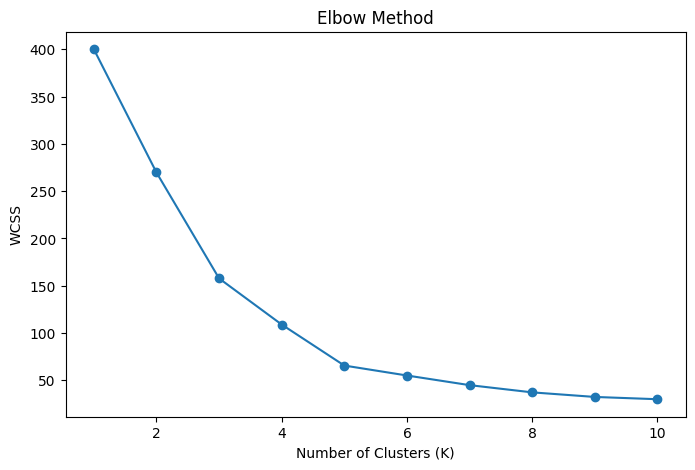

In [ ]:


# ============================================================
# STEP 7: FIND OPTIMAL K USING ELBOW METHOD
# ============================================================


wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()


In [8]:


# ============================================================
# STEP 8: SILHOUETTE SCORE ANALYSIS
# ============================================================

print("\nSilhouette Scores")

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(f"K = {k} --> Score = {score:.4f}")




Silhouette Scores
K = 2 --> Score = 0.3213
K = 3 --> Score = 0.4666
K = 4 --> Score = 0.4939
K = 5 --> Score = 0.5547
K = 6 --> Score = 0.5399
K = 7 --> Score = 0.5281
K = 8 --> Score = 0.4552
K = 9 --> Score = 0.4571
K = 10 --> Score = 0.4432


/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [9]:

# ============================================================
# STEP 9: TRAIN FINAL K-MEANS MODEL
# ============================================================

# Assume optimal K = 5

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print("\nCluster Labels")
print(clusters[:10])



Cluster Labels
[4 2 4 2 4 2 4 2 4 2]


In [10]:


# ============================================================
# STEP 10: ADD CLUSTER LABELS TO DATASET
# ============================================================

df["Cluster"] = clusters

print("\nDataset with Cluster Labels")
print(df.head())



Dataset with Cluster Labels
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


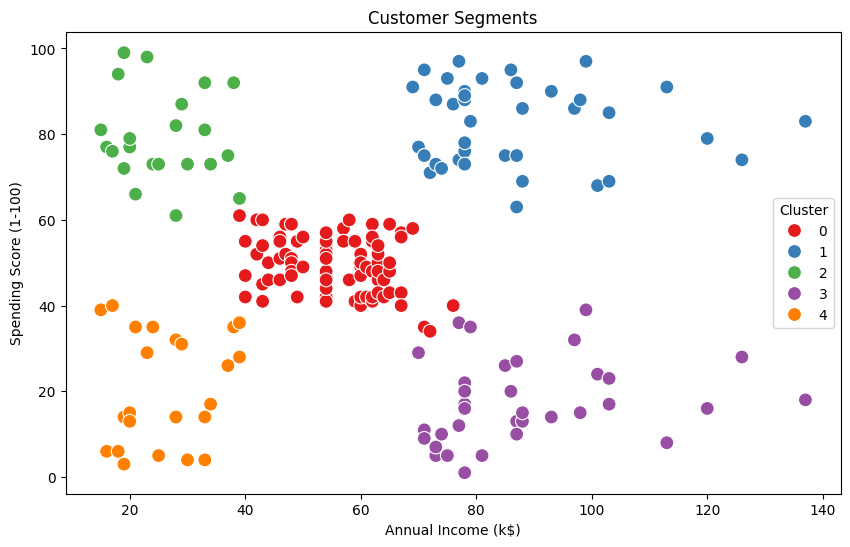

In [11]:


# ============================================================
# STEP 11: VISUALIZE CLUSTERS
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    data=df,
    s=100
)

plt.title("Customer Segments")

plt.show()


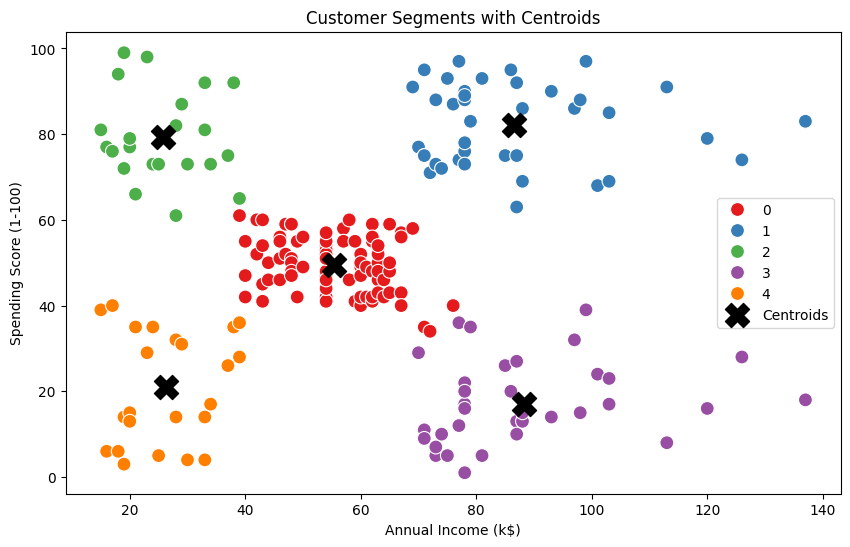

In [12]:


# ============================================================
# STEP 12: VISUALIZE CENTROIDS
# ============================================================

centroids = scaler.inverse_transform(
    kmeans.cluster_centers_
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    data=df,
    palette="Set1",
    s=100
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker='X',
    s=300,
    c='black',
    label='Centroids'
)

plt.legend()

plt.title("Customer Segments with Centroids")

plt.show()


In [13]:


# ============================================================
# STEP 13: CLUSTER ANALYSIS
# ============================================================

cluster_summary = df.groupby("Cluster").mean(
    numeric_only=True
)

print("\nCluster Summary")
print(cluster_summary)



Cluster Summary
         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         86.320988  42.716049           55.296296               49.518519
1        162.000000  32.692308           86.538462               82.128205
2         23.090909  25.272727           25.727273               79.363636
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043


In [14]:


# ============================================================
# STEP 14: CLUSTER COUNTS
# ============================================================

print("\nCustomers in Each Cluster")

print(df["Cluster"].value_counts())



Customers in Each Cluster
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [15]:


# ============================================================
# STEP 15: FINAL SILHOUETTE SCORE
# ============================================================

final_score = silhouette_score(
    X_scaled,
    clusters
)

print("\nFinal Silhouette Score")

print(round(final_score,4))




Final Silhouette Score
0.5547


/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/shailesh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [16]:

# ============================================================
# STEP 16: BUSINESS INTERPRETATION
# ============================================================

print("\nBusiness Insights")

print("""
Cluster 0 --> Budget Customers
Low Income + Low Spending

Cluster 1 --> Premium Customers
High Income + High Spending

Cluster 2 --> Regular Customers
Average Income + Average Spending

Cluster 3 --> Potential Customers
High Income + Low Spending

Cluster 4 --> Impulsive Shoppers
Low Income + High Spending
""")



Business Insights

Cluster 0 --> Budget Customers
Low Income + Low Spending

Cluster 1 --> Premium Customers
High Income + High Spending

Cluster 2 --> Regular Customers
Average Income + Average Spending

Cluster 3 --> Potential Customers
High Income + Low Spending

Cluster 4 --> Impulsive Shoppers
Low Income + High Spending



In [17]:

df.to_csv(
    "Customer_Segmentation_Output.csv",
    index=False
)

print("\nOutput Saved Successfully")
print("File Name: Customer_Segmentation_Output.csv")




Output Saved Successfully
File Name: Customer_Segmentation_Output.csv
